This notebook records the creation of the `SHENDURE_BOUNDS` preset object.

In [9]:
import sys
import os
import scMPRAforge as scm
import pandas as pd
import numpy as np

#load the autoreload extension
%load_ext autoreload
#reload code on every execution
#(this may break objects)
#you can remove this & do dev in a notebook, then paste into the module when you are done.
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
from dask.distributed import Client, LocalCluster
cluster=LocalCluster(memory_limit='8GB')
client=Client(cluster)

2025-08-20 11:54:29,614 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:37171' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {'lambda-3f55a0344ca66f3fb03bfc6ced97470f', 'lambda-5a32fb4fb2816072255a76331d0a78cc', 'lambda-bda54d5a29d708c2392c6701e3bb25ab', 'lambda-944b8462f1c229c2e8810f186867131b', 'lambda-557bea069c39c9efce86295b3443ba31', 'lambda-2909e7bcbb064dcda26e6c33e8bd8d15', 'lambda-268da393b4b3bda8df18d5aab199e313', 'lambda-0919e183946aabc353461a97772fa782', 'lambda-609143e444545a186a52e5748cdb360d', 'lambda-99ee394e0f81a5d22bc65af8ba0e76e4', 'lambda-3d034d28527cc095011145c25014f160', 'lambda-2e45d75f0676be28f5b4c95dda3d72f6', 'lambda-f5ea8ac9a31c26c81c0e028fdfe495a1', 'lambda-bea5199afbdbac018df4f4ed6ff4c3ac', 'lambda-45d19e1bd06a42161032457a0b18cff8', 'lambda-5da5604b7cac6a8aec01df7358e05d94', 'lambda-6a50f2b566ead777ad9909d607ff6839', 'lambda-599f98d588e268e370db6dcda10efeaa', 'lambda-3d9335e3ee485c1767e0b3499b38

In [11]:
path="/gpfs/gibbs/pi/reilly/tabula_data/shendure"
name="ortho_primordial_v3"
data_root="/gpfs/gibbs/pi/reilly/tabula_data"
primordial=scm.ortho.load(client,path,name)

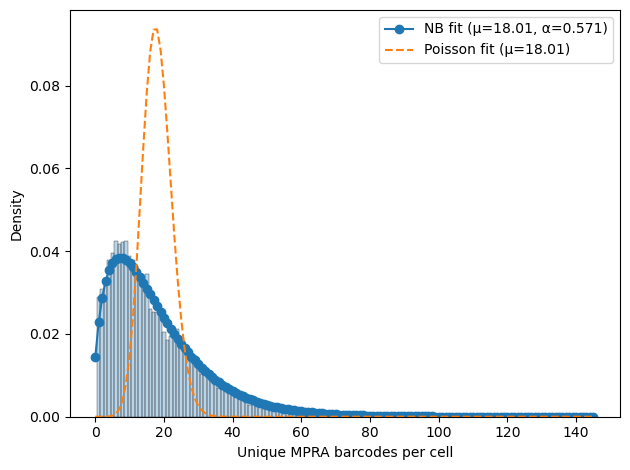

{'poisson_mu': 18.01055567079212,
 'nb_mu': 18.010555670792133,
 'nb_alpha': 0.5705626300443596}

In [12]:
primordial.training_data.describe_transfection(plot=True)

In [13]:
shendure_bounds=scm.Bounds.from_ortho(primordial)

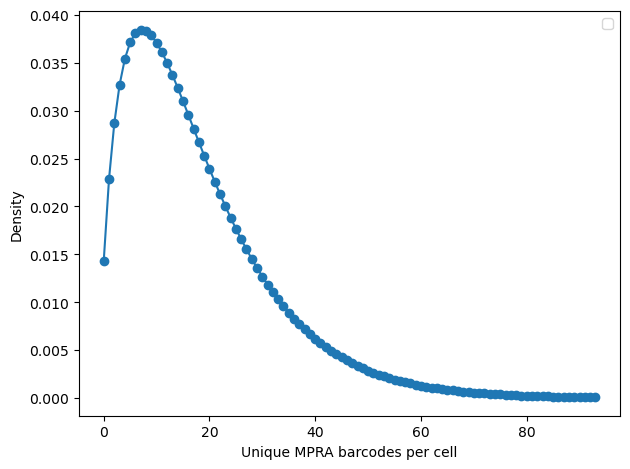

In [14]:
shendure_bounds.plot_transfection()

In [15]:
shendure_bounds.to_tgz("scMPRAforge/presets/shendure_bounds.tgz")

In [16]:
cluster.close()